In [1]:
!pip install tensorboardX rdkit
!pip install rdkit-pypi
import os
from sklearn.model_selection import train_test_split
import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as Data

import numpy as np
from collections import defaultdict
from sklearn.model_selection import LeaveOneOut
import time
from tqdm import tqdm
import numpy as np
import gc
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/Posdoc/Native_AFP/code/')
sys.setrecursionlimit(50000)
import pickle
torch.backends.cudnn.benchmark = True
torch.set_default_tensor_type('torch.cuda.FloatTensor')
# from tensorboardX import SummaryWriter
torch.nn.Module.dump_patches = True
import copy
import pandas as pd
#then import my own modules
from GCN import Fingerprint, GCNModel, save_smiles_dicts, get_smiles_dicts, get_smiles_array, moltosvg_highlight
from rdkit import Chem
# from rdkit.Chem import AllChem
from rdkit.Chem import QED
from rdkit.Chem import rdMolDescriptors, MolSurf
from rdkit.Chem.Draw import SimilarityMaps
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
%matplotlib inline
from numpy.polynomial.polynomial import polyfit
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib.cm as cm
import matplotlib
import seaborn as sns; sns.set_style("darkgrid")
from IPython.display import SVG, display

import itertools
from sklearn.metrics import r2_score
import scipy


import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
import pickle
import os
import time
from rdkit import Chem
from sklearn.model_selection import LeaveOneOut
from collections import defaultdict


device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

/usr/local/lib/python3.11/dist-packages/torch/__init__.py:614: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:451.)
  _C._set_default_tensor_type(t)


cuda


In [2]:
def prepare_model_and_data(raw_filename, target_name='Calx', targets=None, batch_size=50, epochs=800, p_dropout=0.1, fingerprint_dim=150, weight_decay=2, learning_rate=3, radius=3, T=2, per_target_output_units_num=1):
    if targets is None:
        targets = ['H3K4', 'H3K4ac', 'H3K4me1', 'H3K4me2', 'H3K4me3', 'H3K9me3', 'H3R2me2a', 'H3R2me2s']

    feature_filename = raw_filename.replace('.csv', '.pickle')
    filename = raw_filename.replace('.csv', '')
    prefix_filename = raw_filename.split('/')[-1].replace('.csv', '')
    smiles_targets_df = pd.read_csv(raw_filename)

    smilesList = smiles_targets_df.SMILES.values
    print("number of all smiles: ", len(smilesList))

    atom_num_dist = []
    remained_smiles = []
    canonical_smiles_list = []
    for smiles in smilesList:
        try:
            mol = Chem.MolFromSmiles(smiles)
            atom_num_dist.append(len(mol.GetAtoms()))
            remained_smiles.append(smiles)
            canonical_smiles_list.append(Chem.MolToSmiles(Chem.MolFromSmiles(smiles), isomericSmiles=True))
        except:
            print(smiles)
            pass
    print("number of successfully processed smiles: ", len(remained_smiles))

    smiles_targets_df = smiles_targets_df[smiles_targets_df["SMILES"].isin(remained_smiles)]
    smiles_targets_df['cano_smiles'] = canonical_smiles_list

    start_time = str(time.ctime()).replace(':', '-').replace(' ', '_')
    output_units_num = len(targets) * per_target_output_units_num

    if os.path.isfile(feature_filename):
        feature_dicts = pickle.load(open(feature_filename, "rb"))
    else:
        feature_dicts = save_smiles_dicts(smilesList, filename)
    feature_dicts = get_smiles_dicts(smilesList)

    remained_df = smiles_targets_df[smiles_targets_df["cano_smiles"].isin(feature_dicts['smiles_to_atom_mask'].keys())]

    x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, smiles_to_rdkit_list = get_smiles_array([canonical_smiles_list[0]], feature_dicts)
    num_atom_features = x_atom.shape[-1]
    num_bond_features = x_bonds.shape[-1]

    loss_function = nn.MSELoss()
    model = GCNModel(radius, T, num_atom_features, num_bond_features, fingerprint_dim, output_units_num, p_dropout)
    model.to(device)

    optimizer = optim.Adam(model.parameters(), 10**-learning_rate, weight_decay=10**-weight_decay)

    model_parameters = filter(lambda p: p.requires_grad, model.parameters())
    params = sum([np.prod(p.size()) for p in model_parameters])
    #print(params)
    #for name, param in model.named_parameters():
     #   if param.requires_grad:
      #      print(name, param.data.shape)


    return model, optimizer, loss_function, remained_df, targets, feature_dicts



In [3]:
def train(model, dataset, optimizer, loss_function, epoch, batch_size, targets, feature_dicts, ratio_list):
    model.train()
    
    if len(dataset) <= batch_size:
        batch_list = [dataset.index]

    else:
        valList = np.arange(0, dataset.shape[0])
        np.random.shuffle(valList)
        batch_list = [valList[i:i+batch_size] for i in range(0, dataset.shape[0], batch_size)]
    
    device = next(model.parameters()).device
    total_loss = 0
    
    for counter, batch in enumerate(batch_list):
        batch_df = dataset.loc[batch, :]
        smiles_list = batch_df.cano_smiles.values

        x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, _ = get_smiles_array(smiles_list, feature_dicts)
        
        x_atom = torch.Tensor(x_atom).to(device)
        #print(x_atom.shape)
        x_bonds = torch.Tensor(x_bonds).to(device)
        x_atom_index = torch.LongTensor(x_atom_index).to(device)
        x_bond_index = torch.LongTensor(x_bond_index).to(device)
        x_mask = torch.Tensor(x_mask).to(device)
        
        atoms_prediction, mol_prediction = model(x_atom, x_bonds, x_atom_index, x_bond_index, x_mask)
        
        optimizer.zero_grad()
        loss = 0.0
        
        for i, target in enumerate(targets):
            y_pred = mol_prediction[:, i]
            y_val = torch.Tensor(batch_df[target].values).squeeze().to(device)
            target_loss = loss_function(y_pred, y_val) * (ratio_list[i] ** 2)
            loss += target_loss
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(batch_list)

def eval(model, dataset, targets, feature_dicts, batch_size):
    model.eval()
    
    eval_MAE_list = {target: [] for target in targets}
    eval_MSE_list = {target: [] for target in targets}
    y_val_list = {target: [] for target in targets}
    y_pred_list = {target: [] for target in targets}
    smiles_list = []
    
    if len(dataset) <= batch_size:
        batch_list = [dataset.index]
    else:
        valList = np.arange(0, dataset.shape[0])
        batch_list = [valList[i:i+batch_size] for i in range(0, dataset.shape[0], batch_size)]
    
    device = next(model.parameters()).device
    
    with torch.no_grad():
        for batch in batch_list:
            batch_df = dataset.loc[batch, :]
            batch_smiles = batch_df.cano_smiles.values
            smiles_list.extend(batch_smiles)
            
            x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, _ = get_smiles_array(batch_smiles, feature_dicts)
            
            x_atom = torch.Tensor(x_atom).to(device)
            x_bonds = torch.Tensor(x_bonds).to(device)
            x_atom_index = torch.LongTensor(x_atom_index).to(device)
            x_bond_index = torch.LongTensor(x_bond_index).to(device)
            x_mask = torch.Tensor(x_mask).to(device)
            
            atoms_prediction, mol_prediction = model(x_atom, x_bonds, x_atom_index, x_bond_index, x_mask)
            
            for i, target in enumerate(targets):
                y_pred = mol_prediction[:, i].view(-1, 1)
                y_val = torch.Tensor(batch_df[target].values.reshape(-1, 1)).to(device)
                
                MAE = F.l1_loss(y_pred, y_val, reduction='none')
                MSE = F.mse_loss(y_pred, y_val, reduction='none')
                
                y_pred_list[target].extend(y_pred.cpu().numpy().flatten())
                y_val_list[target].extend(y_val.cpu().numpy().flatten())
                
                eval_MAE_list[target].extend(MAE.cpu().numpy().flatten())
                eval_MSE_list[target].extend(MSE.cpu().numpy().flatten())
    
    eval_MAE = np.array([np.mean(eval_MAE_list[target]) for target in targets])
    eval_MSE = np.array([np.mean(eval_MSE_list[target]) for target in targets])
    
    return eval_MAE, eval_MSE, y_pred_list, y_val_list, smiles_list

def train_and_evaluate(model, remained_df, targets, feature_dicts, optimizer, loss_function, 
                      batch_size, num_epochs, patience=30, min_delta=0.001, 
                      prefix_filename='', start_time=''):
    # Initialize tracking structures
    fold_results = []
    regression = {}
    best_param = {
        "train_epoch": 0, 
        "val_epoch": 0, 
        "train_MSE": float('inf'), 
        "val_MSE": float('inf')
    }
    
    # Prediction containers
    prediction_containers = {
        'train': {t: {'pred': [], 'actual': []} for t in targets},
        'test': {t: {'pred': [], 'actual': []} for t in targets}
    }
    
    # Cross-validation setup
    loo = LeaveOneOut()
    initial_state = model.state_dict()
    host_results = {}
    
    for fold, (train_index, test_index) in enumerate(loo.split(remained_df)):
        # --- Fold Initialization ---
        # Reset model and optimizer
        model.load_state_dict(initial_state)
        optimizer = type(optimizer)(model.parameters(), **optimizer.defaults)  # Proper reset
        
        # Data splits
        train_df = remained_df.iloc[train_index]
        test_df = remained_df.iloc[test_index]
        current_smile = test_df['Host'].values[0]
        
        # Validation split with minimum size
        val_size = max(5, int(0.1 * len(train_df)))
        train_df, val_df = train_test_split(
            train_df, 
            test_size=val_size,
            stratify=pd.qcut(train_df[targets[0]], q=5) if len(targets) > 0 else None
        )
        
        # --- Training Loop ---
        best_val_mse = float('inf')
        epochs_no_improve = 0
        best_model_state = None
        best_val_metrics = None
        
        for epoch in range(num_epochs):
            # Training phase
            train_loss = train(model, train_df, optimizer, loss_function, epoch, 
                              batch_size, targets, feature_dicts, ratio_list=[1.0]*len(targets))
            
            # Validation evaluation
            val_metrics = eval(model, val_df, targets, feature_dicts, batch_size)
            val_mae, val_mse = val_metrics[0].mean(), val_metrics[1].mean()
            
            # Model checkpointing based on validation
            if val_mse < best_val_mse - min_delta:
                best_val_mse = val_mse
                epochs_no_improve = 0
                best_model_state = model.state_dict()
                best_val_metrics = val_metrics
                best_param.update({
                    "val_epoch": epoch,
                    "val_MSE": val_mse,
                    "train_epoch": epoch,
                    "train_MSE": train_loss  # Using actual training loss
                })
            else:
                epochs_no_improve += 1
            
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
        
        # --- Post-Training Evaluation ---
        # Load best model
        model.load_state_dict(best_model_state)
        
        # Re-evaluate all sets with best model
        final_train_metrics = eval(model, train_df, targets, feature_dicts, batch_size)
        final_val_metrics = best_val_metrics
        test_metrics = eval(model, test_df, targets, feature_dicts, batch_size)
        test_MAE, test_MSE, test_pred, test_actual, _ = test_metrics
        
        # Store results by host
        host_results[current_smile] = {
            target: {
                "actual": float(test_actual[target][0]),  # Convert to Python float
                "predicted": float(test_pred[target][0])
            }
            for target in targets
        }
        # Store predictions
        for target in targets:
            # Training data (from final evaluation)
            prediction_containers['train'][target]['pred'].extend(final_train_metrics[2][target])
            prediction_containers['train'][target]['actual'].extend(final_train_metrics[3][target])
            
            # Test data
            prediction_containers['test'][target]['pred'].extend(test_metrics[2][target])
            prediction_containers['test'][target]['actual'].extend(test_metrics[3][target])
        
        # --- Fold Bookkeeping ---
        fold_results.append({
            'fold': fold + 1,
            'smiles': current_smile,
            'train_metrics': {
                'MAE': final_train_metrics[0].tolist(),
                'MSE': final_train_metrics[1].tolist()
            },
            'val_metrics': {
                'MAE': final_val_metrics[0].tolist(),
                'MSE': final_val_metrics[1].tolist()
            },
            'test_metrics': {
                'MAE': test_metrics[0].tolist(),
                'MSE': test_metrics[1].tolist()
            }
        })
        
        print(f"\nFold {fold+1} Summary:")
        print(f"Train MSE: {np.mean(final_train_metrics[1]):.4f}")
        print(f"Val MSE: {np.mean(final_val_metrics[1]):.4f}")
        print(f"Test MSE: {np.mean(test_metrics[1]):.4f}")
    
    # --- Final Aggregation ---
    def calculate_overall(metric_key):
        train_vals = [np.mean(f['train_metrics'][metric_key]) for f in fold_results]
        test_vals = [np.mean(f['test_metrics'][metric_key]) for f in fold_results]
        return np.mean(train_vals), np.mean(test_vals)
    
    overall_train_mae, overall_test_mae = calculate_overall('MAE')
    overall_train_mse, overall_test_mse = calculate_overall('MSE')
    
    print("\nFinal Performance:")
    print(f"Train MAE: {overall_train_mae:.4f} ± {np.std([f['train_metrics']['MAE'] for f in fold_results]):.4f}")
    print(f"Test MAE: {overall_test_mae:.4f} ± {np.std([f['test_metrics']['MAE'] for f in fold_results]):.4f}")
    print(f"Train MSE: {overall_train_mse:.4f} ± {np.std([f['train_metrics']['MSE'] for f in fold_results]):.4f}")
    print(f"Test MSE: {overall_test_mse:.4f} ± {np.std([f['test_metrics']['MSE'] for f in fold_results]):.4f}")
    
    return {
        "host_predictions": host_results,  
        "overall_metrics": (overall_train_mae, overall_train_mse, 
                           overall_test_mae, overall_test_mse),
        "fold_results": fold_results,
        "train_predictions": prediction_containers['train'],
        "test_predictions": prediction_containers['test']
    }


In [4]:
raw_filename= '/notebooks/Codebase/Database/calix smiles small set.csv'
model, optimizer, loss_function, remained_df, targets, feature_dicts= prepare_model_and_data(raw_filename,
                                                                                            target_name='Calx', targets=None, batch_size=38, epochs=800,
                                                                                             p_dropout=0.1, fingerprint_dim=150, weight_decay=2, learning_rate=3, radius=3,
                                                                                             T=2, per_target_output_units_num=1)

results = train_and_evaluate(model, remained_df, targets, feature_dicts, optimizer, loss_function, batch_size=38, num_epochs=800)                                                                        

number of all smiles:  28
number of successfully processed smiles:  28
Early stopping at epoch 127

Fold 1 Summary:
Train MSE: 1.2378
Val MSE: 0.5953
Test MSE: 2.0249
Early stopping at epoch 47

Fold 2 Summary:
Train MSE: 0.6932
Val MSE: 1.4436
Test MSE: 4.8550
Early stopping at epoch 95

Fold 3 Summary:
Train MSE: 0.8085
Val MSE: 0.8881
Test MSE: 2.1530
Early stopping at epoch 56

Fold 4 Summary:
Train MSE: 0.7257
Val MSE: 1.1898
Test MSE: 1.4640
Early stopping at epoch 63

Fold 5 Summary:
Train MSE: 0.5913
Val MSE: 0.7017
Test MSE: 1.2367
Early stopping at epoch 84

Fold 6 Summary:
Train MSE: 0.4676
Val MSE: 0.8673
Test MSE: 0.4145
Early stopping at epoch 41

Fold 7 Summary:
Train MSE: 0.4345
Val MSE: 0.4616
Test MSE: 0.2981
Early stopping at epoch 71

Fold 8 Summary:
Train MSE: 0.2886
Val MSE: 1.1583
Test MSE: 1.5956
Early stopping at epoch 56

Fold 9 Summary:
Train MSE: 0.3322
Val MSE: 0.6992
Test MSE: 1.6063
Early stopping at epoch 35

Fold 10 Summary:
Train MSE: 0.4089
Val MSE: 0

In [5]:
host_preds = results["host_predictions"]


for smiles, preds in host_preds.items():
    print(f"\nHost: {smiles}")
    for target_name, values in preds.items():
        print(f"{target_name}:")
        print(f"  Actual: {values['actual']:.4f}")
        print(f"  Predicted: {values['predicted']:.4f}")
        print(f"  Error: {abs(values['actual']-values['predicted']):.4f}")

# Get specific host data:
specific_host = list(host_preds.keys())[0]
print(f"\nFirst host details: {host_preds[specific_host]}")


Host: AP8
H3K4:
  Actual: -1.3093
  Predicted: -0.2797
  Error: 1.0296
H3K4ac:
  Actual: 0.0000
  Predicted: -0.1835
  Error: 0.1835
H3K4me1:
  Actual: -3.0791
  Predicted: -1.4237
  Error: 1.6554
H3K4me2:
  Actual: -5.1850
  Predicted: -3.3079
  Error: 1.8771
H3K4me3:
  Actual: -5.0207
  Predicted: -3.2439
  Error: 1.7768
H3K9me3:
  Actual: -3.7723
  Predicted: -2.8747
  Error: 0.8975
H3R2me2a:
  Actual: -4.1997
  Predicted: -2.5113
  Error: 1.6884
H3R2me2s:
  Actual: -2.6037
  Predicted: -1.1795
  Error: 1.4242

Host: AH4
H3K4:
  Actual: -0.1165
  Predicted: 0.7769
  Error: 0.8935
H3K4ac:
  Actual: 1.4110
  Predicted: 1.2990
  Error: 0.1120
H3K4me1:
  Actual: -2.2073
  Predicted: 0.0002
  Error: 2.2075
H3K4me2:
  Actual: -5.2983
  Predicted: -1.0600
  Error: 4.2383
H3K4me3:
  Actual: -3.5066
  Predicted: -1.2778
  Error: 2.2287
H3K9me3:
  Actual: -2.2073
  Predicted: -0.5124
  Error: 1.6949
H3R2me2a:
  Actual: -2.3330
  Predicted: -0.2125
  Error: 2.1205
H3R2me2s:
  Actual: -1.4271


Overall R² score: 0.2019


AttributeError: module 'matplotlib.pyplot' has no attribute 'xtlabelsize'

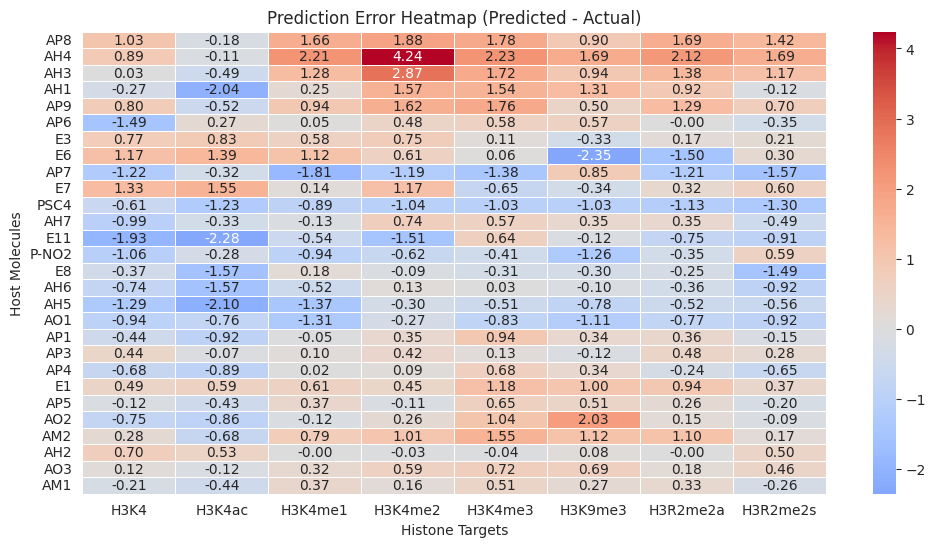

In [6]:
import numpy as np
from sklearn.metrics import r2_score

def calculate_overall_r2(data):
    all_predicted = []
    all_actual = []
    
    for compound in data.values():
        for histone_mod in compound.values():
            all_predicted.append(histone_mod['predicted'])
            all_actual.append(histone_mod['actual'])

    all_predicted = np.array(all_predicted)
    all_predicted = np.exp(all_predicted)
    
    all_actual = np.array(all_actual)
    all_actual = np.exp(all_actual)
    overall_r2 = r2_score(all_actual, all_predicted)
    return overall_r2

# Assuming your dictionary is stored in a variable called 'data'
overall_r2 = calculate_overall_r2(host_preds)

print(f"Overall R² score: {overall_r2:.4f}")



# Create error matrix
error_data = []
hosts = list(host_preds.keys())
targets = list(host_preds[hosts[0]].keys())  # Get first host's targets

for host in hosts:
    row = []
    for target in targets:
        actual = host_preds[host][target]['actual']
        predicted = host_preds[host][target]['predicted']
        row.append(predicted - actual)  # Calculate error
    error_data.append(row)

# Create DataFrame
df = pd.DataFrame(error_data, index=hosts, columns=targets)

# Create heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df, 
            annot=True, 
            fmt=".2f",
            cmap='coolwarm', 
            center=0,
            linewidths=0.5,
            annot_kws={"size": 10})

plt.title("Prediction Error Heatmap (Predicted - Actual)")
plt.xlabel("Histone Targets")
plt.ylabel("Host Molecules")
plt.xtlabelsize(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
import pickle

# Assuming your dictionary is named 'results' and the specific dictionary you want to save is at index 5
dictionary_to_save = host_preds

# Specify the file name where you want to save the pickle file
file_name = "/notebooks/Codebase/Result_dict/LOO GCN abs_val Small Dataset.pkl"

# Open the file in binary write mode and save the dictionary
with open(file_name, "wb") as file:
    pickle.dump(dictionary_to_save, file)

print(f"Dictionary saved as {file_name}")

Dictionary saved as /notebooks/Codebase/Result_dict/LOO GCN abs_val Small Dataset.pkl


In [8]:
result_dict= pd.read_pickle('/notebooks/Codebase/Result_dict/LOO GCN abs_val Small Dataset.pkl')
overall_r2 = calculate_overall_r2(result_dict)
overall_r2

0.20186722349072805